[Spreadsheet](https://docs.google.com/spreadsheets/d/1Jp20BP1jxn1tQpTd8C3H1F8FJvhNqxhywOxBSAVCw7c/edit?usp=sharing)

## **Todos**

* Achive 85+ accuracy on whole data

# Pytorch Food 101

To make a generalize model that tuned with 20% of classes you should make sure that 20% of classes represent the whole dataset.

On full dataset some scaling adjustments may be needed for the full dataset for lr, batch size and etc.


| Setting                                                    | Top-1 Accuracy | Notes                                                 |
| ---------------------------------------------------------- | -------------- | ----------------------------------------------------- |
| Full dataset (101 classes, 750 training images/class)      | **\~86–88%**   | Standard fine-tuning of pretrained ResNet50           |
| Full dataset + stronger augmentations (RandAugment, Mixup) | **\~88–90%**   | Slight improvements with better regularization        |
| Only 20% of classes or subset of data                      | **\~80–87%**   | Depends heavily on class difficulty and augmentations |


## **Outlines**

1. Download Food-101 Dataset (20% and 100%)
2. Load and Visualize Data
3. Create Test, Train and Eval Functions
**Each Model Loop:**
4. Load, Transform and use Dataloader
5. Use a Pretrained Model (Transfer Learning)
6. Train, Val and Evaluate the Model
7. Repeat the Model Loop to Customize the Selected Model and beat 80% or 90% accuracy **top-1**
**End Loop**
8. Eval the Best Model with test dataset
9. Use 100% of Dataset(Maybe)
10. Save and Load the best Model

## **0. Imports**

In [ ]:
import os
import time
import random
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2 as cv
from PIL import Image
from google.colab.patches import cv2_imshow as imshow

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Extract tar files
import tarfile

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
from torchvision import datasets, transforms
import torchvision.models as models

torch.__version__, torchvision.__version__

('2.8.0+cu126', '0.23.0+cu126')

## **1. Constants**

In [ ]:
RANDOM_SEED = 42

# 100% of Data
# DATA_LINK, WGET = "http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz", True

# 20% of Data
DATA_LINK, WGET = "https://drive.google.com/file/d/1Kd3cq5St2gcRqZ4xRu-uT90wYTpii5in/view?usp=sharing", False

BATCH_SIZE = 32

## **2. Device Agnostic**

In [ ]:
DEVICE = "mps" if torch.mps.is_available() else "cpu"
DEVICE = "cuda" if torch.cuda.is_available() else DEVICE
DEVICE

'cuda'

Check GPU(s) Details

In [ ]:
if DEVICE == "cuda":
  !nvidia-smi

Thu Aug 21 21:29:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **3. Download Data**

### 3.0 Download and Extract

In [ ]:
import gdown

output_path = 'food_101.tar.gz'

if WGET:
  # 100%
  !wget -O {output_path} {DATA_LINK}
else:
  # 20%
  file_id = DATA_LINK.split("/")[-2]
  gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=True)

In [ ]:
# Setup path to data folder
data_path = Path("data/")
image_path_f = data_path / "food_101"

# If the image folder doesn't exist, download it and prepare it...
if image_path_f.is_dir():
    print(f"{image_path_f} directory exists.")
else:
    print(f"Did not find {image_path_f} directory, creating one...")
    image_path_f.mkdir(parents=True, exist_ok=True)

    # Define the path to your .tar.gz file
    file_name = output_path

    # Define the destination directory where you want to extract the contents
    destination_folder = image_path_f

    try:
        # Open the tar.gz file in read mode ('r:gz')
        # The 'with' statement ensures the file is properly closed even if errors occur
        with tarfile.open(file_name, 'r:gz') as tar:
            # Extract all contents to the specified destination folder
            tar.extractall(path=destination_folder)
        print(f"Successfully extracted '{file_name}' to '{destination_folder}'.")
    except tarfile.ReadError:
        print(f"Error: Could not open or read '{file_name}'. It might be corrupted or not a valid tar.gz file.")
    except FileNotFoundError:
        print(f"Error: The file '{file_name}' was not found.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Did not find data/food_101 directory, creating one...


/tmp/ipython-input-3346302704.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=destination_folder)


Successfully extracted 'food_101.tar.gz' to 'data/food_101'.


In [ ]:
image_path = Path(os.path.join(image_path_f, "food-101", "images"))
print(image_path)

data/food_101/food-101/images


### 3.1. Walkthrough image_path

In [ ]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [ ]:
walk_through_dir(image_path)

There are 20 directories and 0 images in 'data/food_101/food-101/images'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/crab_cakes'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/red_velvet_cake'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/chicken_quesadilla'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/pho'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/cheesecake'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/waffles'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/chicken_curry'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/seaweed_salad'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/steak'.
There are 0 directories and 1000 images in 'data/food_101/food-101/images/spring_rolls'.
There are 0 directories and 1000 images in 'data/f

## **4. Load and Visualize Data**

For explorations and visualizations

### 4.0. Load

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
dataset = datasets.ImageFolder(image_path, transform=transform)

### 4.1. Explore

In [ ]:
len(dataset)

20000

In [ ]:
class_names = dataset.classes
print(class_names)

['baby_back_ribs', 'baklava', 'bibimbap', 'bruschetta', 'caesar_salad', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'crab_cakes', 'cup_cakes', 'filet_mignon', 'fried_calamari', 'pancakes', 'pho', 'red_velvet_cake', 'samosa', 'seaweed_salad', 'spring_rolls', 'steak', 'waffles']


### 4.2. Visualize

In [ ]:
def display_random_imgs(dataset: torch.utils.data.Dataset,
                        sample_size: int = 9,
                        num_of_cols: int = 3,
                        display_shape: bool=True,
                        seed: int=None
                        ):
  ## Apply random seed
  if seed:
    random.seed(seed)
    np.random.seed(seed)

  ## Select samples randomly
  idxs = np.random.randint(low=0, high=len(dataset), size=(sample_size, ))

  cols = num_of_cols
  rows = (sample_size // cols) + 1 if sample_size % 3 != 0 else sample_size // cols

  plt.figure(figsize=(3 * cols, 3 * rows))

  for i, image_idx in enumerate(idxs):
    img = dataset[image_idx][0].cpu().numpy()
    label = dataset[image_idx][1]
    class_name = dataset.classes[label]

    plt.subplot(rows, cols, i + 1)

    img = np.transpose(img, (1, 2, 0))
    plt.imshow(img)
    if display_shape:
      class_name += " " + str(img.shape)
    plt.title(class_name, fontsize=10)

    plt.axis(False)

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed=None):
    """
    Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    if seed:
      random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

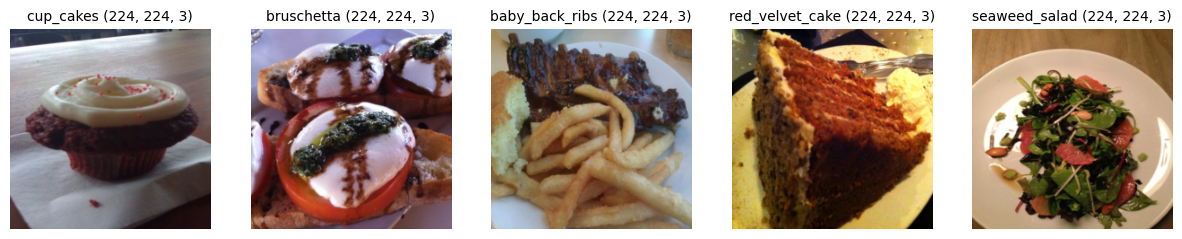

In [ ]:
display_random_imgs(dataset, sample_size=5, num_of_cols=5, display_shape=True, seed=None)

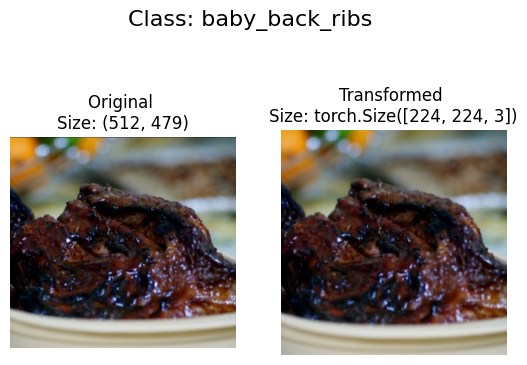

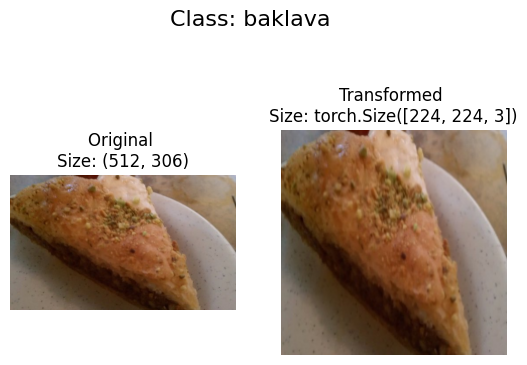

In [ ]:
image_path_list = list(Path(image_path).glob("*/*.jpg"))

plot_transformed_images(image_path_list, transform=transform, n=2, seed=None)

## **5. Test Train Eval Functions**

### 5.0. Train

In [ ]:
def train_step(model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               dataloader: torch.utils.data.DataLoader,
               device: torch.device = "cpu"
               ):
  # model.to(device)
  model.train()

  total_loss = 0.0
  total_correct_predictions = 0
  total_samples = 0

  for batch, (data, target) in enumerate(dataloader):
    data, target = data.to(device), target.to(device)

    # Forward pass
    y_logits = model(data)

    # Calculate the Loss
    loss = loss_fn(y_logits, target)
    total_loss += (loss.item() * target.size(0))

    # Count correct
    total_correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
    total_samples += target.size(0)

    # Zero Grad
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Apply Grad
    optimizer.step()

  avg_loss = total_loss / total_samples
  accuracy = total_correct_predictions / total_samples * 100

  print(f"Train loss: {avg_loss:.5f} | Train accuracy: {accuracy:.2f}%")

  return (avg_loss, accuracy)

### 5.1. Test

In [ ]:
def test_step(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              device: torch.device = "cpu"
              ):

  # model.to(device)
  model.eval()

  total_loss = 0.0
  total_correct_predictions = 0
  total_samples = 0

  with torch.inference_mode():
    for batch, (data, target) in enumerate(dataloader):
      data, target = data.to(device), target.to(device)

      # Forward pass
      y_logits = model(data)

      # Calculate the Loss
      loss = loss_fn(y_logits, target)
      total_loss += (loss.item() * target.size(0))

      # Count correct
      total_correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
      total_samples += target.size(0)

  avg_loss = total_loss / total_samples
  accuracy = total_correct_predictions / total_samples * 100

  print(f"Test loss: {avg_loss:.5f} | Test accuracy: {accuracy:.2f}%")

  return (avg_loss, accuracy)

### 5.2. Eval

In [ ]:
def eval_model(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               device: torch.device = "cpu") -> tuple[np.ndarray, torch.Tensor, torch.Tensor]:
    """
    Return probability, prediction, and target of all samples as 1D tensors.
    """
    model.to(device)
    model.eval()

    y_probs = []
    y_preds = []
    targets = []

    with torch.inference_mode():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)

            # Forward pass
            y_logits = model(data)

            # Softmax probabilities and predictions
            probs = torch.softmax(y_logits, dim=1).max(dim=1).values
            preds = torch.argmax(y_logits, dim=1)

            y_probs.append(probs)
            y_preds.append(preds)
            targets.append(target)

    # Convert to proper types
    y_prob_np = torch.cat(y_probs).cpu().numpy()
    y_pred_tensor = torch.cat(y_preds).cpu()
    target_tensor = torch.cat(targets).cpu()

    return y_prob_np, y_pred_tensor, target_tensor

## **6. Model 3**

**EfficientNet_V2_S**


| Weight | Acc@1 | Acc@5 | Params | GFLOPS |
|---|---|---|---|---|
|ResNet50_Weights.IMAGENET1K_V2| 80.858 | 95.434 | 25.6M | 4.09 |
|EfficientNet_V2_S_Weights.IMAGENET1K_V1| 84.228 | 96.878 | 21.5M | 8.37 |












### 6.0. Load a Pretrained Model

Load Model + Weights

In [ ]:
# torchvision.models
weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
efficientnet_v2_s_model = models.efficientnet_v2_s(weights=weights)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 195MB/s]


Model Defualt Transforms

In [ ]:
weights.transforms()

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 6.1. Load Transform Dataloader

#### 6.1.0. Transform

In [ ]:
# EfficientNet_V2_S Basic
train_transform = transforms.Compose([
    transforms.Resize(384), # EfficientNet_V2_S expects 384x384
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(384), # EfficientNet_V2_S expects 384x384
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#### 6.1.1. Load

 70% Train, 20% Test, 10% Val

In [ ]:
# load datasets with different transforms
dataset_train = datasets.ImageFolder(image_path, transform=train_transform)
dataset_eval  = datasets.ImageFolder(image_path, transform=test_transform)  # same images but different transform
targets = dataset_train.targets  # class indices
class_names = dataset_train.classes

# first: split off test set (20%)
train_idx, test_idx = train_test_split(
    range(len(dataset_train)),
    test_size=0.2,   # 20% test
    stratify=targets,
    random_state=RANDOM_SEED
)

# update targets for the remaining train split
train_targets = [targets[i] for i in train_idx]

# second: split train into train (70%) and val (10%)
train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.125,   # 0.125 of 80% = 10%
    stratify=train_targets,
    random_state=RANDOM_SEED
)

# subsets with the correct transforms
train_dataset = Subset(dataset_train, train_idx)
val_dataset   = Subset(dataset_eval, val_idx)
test_dataset  = Subset(dataset_eval, test_idx)

#### 6.1.2. DataLoader

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

In [ ]:
print(f"Length of train dataloader: {len(train_dataloader)} batches of {train_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")
print(f"Length of val dataloader: {len(val_dataloader)} batches of {val_dataloader.batch_size} (drop last batch is {val_dataloader.drop_last})")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {test_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")

Length of train dataloader: 438 batches of 32 (drop last batch is False)
Length of val dataloader: 63 batches of 32 (drop last batch is False)
Length of test dataloader: 125 batches of 32 (drop last batch is False)


### 6.2. Model Architecture

In [ ]:
%%capture
!pip install torchinfo

In [ ]:
from torchinfo import summary

summary(efficientnet_v2_s_model, input_size=(1, 3, 383, 383))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 1000]                 --
├─Sequential: 1-1                                       [1, 1280, 12, 12]         --
│    └─Conv2dNormActivation: 2-1                        [1, 24, 192, 192]         --
│    │    └─Conv2d: 3-1                                 [1, 24, 192, 192]         648
│    │    └─BatchNorm2d: 3-2                            [1, 24, 192, 192]         48
│    │    └─SiLU: 3-3                                   [1, 24, 192, 192]         --
│    └─Sequential: 2-2                                  [1, 24, 192, 192]         --
│    │    └─FusedMBConv: 3-4                            [1, 24, 192, 192]         5,232
│    │    └─FusedMBConv: 3-5                            [1, 24, 192, 192]         5,232
│    └─Sequential: 2-3                                  [1, 48, 96, 96]           --
│    │    └─FusedMBConv: 3-6                         

### 6.3. Modify the Model

Freeze the early layers

In [ ]:
for name, params in efficientnet_v2_s_model.named_parameters():
  params.requires_grad = False
  # print(name)

Modify the Final Layer

In [ ]:
efficientnet_v2_s_model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [ ]:
num_classes = len(class_names)
in_features = efficientnet_v2_s_model.classifier[1].in_features

efficientnet_v2_s_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=in_features, out_features=num_classes, bias=True)
)

### 6.4. Train the Model

In [ ]:
### Trainable Params
[n for n, p in efficientnet_v2_s_model.named_parameters() if p.requires_grad]

['classifier.1.weight', 'classifier.1.bias']

In [ ]:
efficientnet_v2_s_model = efficientnet_v2_s_model.to(DEVICE)

loss_fn = nn.CrossEntropyLoss()

# Collect only trainable params
trainable_params = [p for p in efficientnet_v2_s_model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable_params, lr=1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# step_size=5 → after every 4 calls to scheduler.step(), the learning rate is multiplied by gamma.
# gamma=0.5 → reduces the LR by a factor of 0.5.

In [ ]:
epochs = 5
logs = []

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

for epoch in range(epochs):
  print(f"epoch: {epoch}\n\n{'-' * (7 + len(str(epoch)))}")
  start_time = time.time()

  train_loss, _ = train_step(model=efficientnet_v2_s_model,
                            loss_fn=loss_fn,
                            optimizer=optimizer,
                            dataloader=train_dataloader,
                            device=DEVICE)

  # scheduler.step()

  val_loss, _ = test_step(model=efficientnet_v2_s_model,
                          loss_fn=loss_fn,
                          dataloader=val_dataloader,
                          device=DEVICE)

  logs.append([epoch, train_loss, val_loss])
  print(f"Epoch time: {time.time() - start_time:.2f}s\n")

epoch: 0

--------
Train loss: 1.64510 | Train accuracy: 58.57%
Test loss: 1.08565 | Test accuracy: 70.50%
Epoch time: 162.46s

epoch: 1

--------
Train loss: 1.06389 | Train accuracy: 69.93%
Test loss: 0.94999 | Test accuracy: 72.95%
Epoch time: 161.79s

epoch: 2

--------
Train loss: 0.95251 | Train accuracy: 72.16%
Test loss: 0.89096 | Test accuracy: 74.05%
Epoch time: 160.81s

epoch: 3

--------
Train loss: 0.88847 | Train accuracy: 72.79%
Test loss: 0.85025 | Test accuracy: 74.45%
Epoch time: 162.15s

epoch: 4

--------
Train loss: 0.86652 | Train accuracy: 73.41%
Test loss: 0.83437 | Test accuracy: 74.85%
Epoch time: 160.42s



### 6.5. Loss Curve

In [ ]:
for i in range(len(logs)):
  logs[i][0] = i

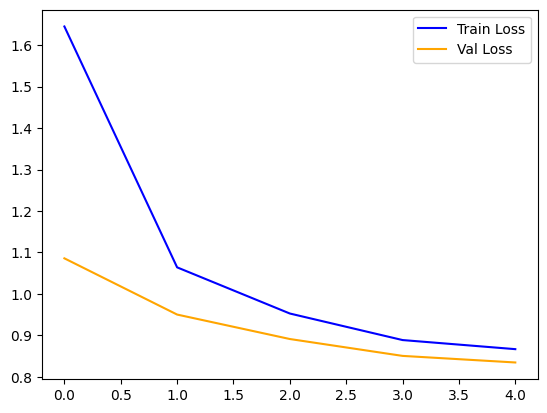

In [ ]:
logs_array = np.array(logs)

plt.plot(logs_array[:, 0], logs_array[:, 1], label="Train Loss", c="b")
plt.plot(logs_array[:, 0], logs_array[:, 2], label="Val Loss", c="orange")

plt.legend()
plt.show()

### 6.6. Evaluate the Model

In [ ]:
probs, preds, targets = eval_model(model=efficientnet_v2_s_model, dataloader=val_dataloader, device=DEVICE)

In [ ]:
# print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy()))
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy(), target_names=class_names))

                    precision    recall  f1-score   support

    baby_back_ribs       0.69      0.72      0.70       100
           baklava       0.79      0.76      0.78       100
          bibimbap       0.87      0.85      0.86       100
        bruschetta       0.70      0.69      0.69       100
      caesar_salad       0.69      0.82      0.75       100
        cheesecake       0.74      0.64      0.68       100
     chicken_curry       0.87      0.72      0.79       100
chicken_quesadilla       0.88      0.80      0.84       100
        crab_cakes       0.59      0.64      0.62       100
         cup_cakes       0.81      0.89      0.85       100
      filet_mignon       0.47      0.62      0.53       100
    fried_calamari       0.82      0.91      0.86       100
          pancakes       0.81      0.74      0.77       100
               pho       0.91      0.92      0.92       100
   red_velvet_cake       0.73      0.81      0.77       100
            samosa       0.67      0.84

## **7. Model 2**

**ResNet50**


| Weight | Acc@1 | Acc@5 | Params | GFLOPS |
|---|---|---|---|---|
|ResNet50_Weights.IMAGENET1K_V2| 80.858 | 95.434 | 25.6M | 4.09 |
|EfficientNet_V2_S_Weights.IMAGENET1K_V1| 84.228 | 96.878 | 21.5M | 8.37 |












### 7.0. Load a Pretrained Model

Load Model + Weights

In [ ]:
# torchvision.models
weights = models.ResNet50_Weights.IMAGENET1K_V2
resnet50_model = models.resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


Model Defualt Transforms

In [ ]:
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 7.1. Load Transform Dataloader

#### 7.1.0. Transform

```python
transforms.Resize(232)
```

(this keeps aspect ratio and scales so that min side = 232)

In [ ]:
# # resnet50 Basic
# train_transform = transforms.Compose([
#     transforms.Resize(232),
#     transforms.CenterCrop(224), # resnet50 expects 224x224
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# test_transform = transforms.Compose([
#     transforms.Resize(232),
#     transforms.CenterCrop(224), # resnet50 expects 224x224
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

In [ ]:
# # resnet50 TrivialAugmentWide
# train_transform = transforms.Compose([
#     transforms.Resize(232),
#     transforms.CenterCrop(224), # resnet50 expects 224x224
#     transforms.TrivialAugmentWide(num_magnitude_bins=24),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# test_transform = transforms.Compose([
#     transforms.Resize(232),
#     transforms.CenterCrop(224), # resnet50 expects 224x224
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

In [ ]:
# # resnet50 Heavy 0
# train_transform = transforms.Compose([
#     transforms.Resize(232),
#     transforms.CenterCrop(224),       # resnet50 expects 224x224
#     transforms.RandomHorizontalFlip(p=0.5),  # Random horizontal flip
#     transforms.RandomVerticalFlip(p=0.25),   # Optional: vertical flip
#     transforms.ColorJitter(                  # Random brightness, contrast, saturation, hue
#         brightness=0.2,
#         contrast=0.2,
#         saturation=0.2,
#         hue=0.1
#     ),
#     transforms.RandomRotation(15),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# test_transform = transforms.Compose([
#     transforms.Resize(232),  # ResNet expects 224x224
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

In [ ]:
# resnet50 Heavy 1
train_transform = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),       # resnet50 expects 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # Random horizontal flip
    transforms.RandomVerticalFlip(p=0.5),   # Optional: vertical flip
    transforms.ColorJitter(                  # Random brightness, contrast, saturation, hue
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(232),  # ResNet expects 224x224
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#### 7.1.1. Load

 70% Train, 20% Test, 10% Val

In [ ]:
# load datasets with different transforms
dataset_train = datasets.ImageFolder(image_path, transform=train_transform)
dataset_eval  = datasets.ImageFolder(image_path, transform=test_transform)  # same images but different transform
targets = dataset_train.targets  # class indices
class_names = dataset_train.classes

# first: split off test set (20%)
train_idx, test_idx = train_test_split(
    range(len(dataset_train)),
    test_size=0.2,   # 20% test
    stratify=targets,
    random_state=RANDOM_SEED
)

# update targets for the remaining train split
train_targets = [targets[i] for i in train_idx]

# second: split train into train (70%) and val (10%)
train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.125,   # 0.125 of 80% = 10%
    stratify=train_targets,
    random_state=RANDOM_SEED
)

# subsets with the correct transforms
train_dataset = Subset(dataset_train, train_idx)
val_dataset   = Subset(dataset_eval, val_idx)
test_dataset  = Subset(dataset_eval, test_idx)

#### 7.1.2. DataLoader

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

In [ ]:
print(f"Length of train dataloader: {len(train_dataloader)} batches of {train_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")
print(f"Length of val dataloader: {len(val_dataloader)} batches of {val_dataloader.batch_size} (drop last batch is {val_dataloader.drop_last})")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {test_dataloader.batch_size} (drop last batch is {train_dataloader.drop_last})")

Length of train dataloader: 438 batches of 32 (drop last batch is False)
Length of val dataloader: 63 batches of 32 (drop last batch is False)
Length of test dataloader: 125 batches of 32 (drop last batch is False)


### 7.2. Model Architecture

In [ ]:
%%capture
!pip install torchinfo

In [ ]:
from torchinfo import summary

summary(resnet50_model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

### 7.3. Modify the Model

Freeze the early layers

In [ ]:
# # Unfreeze only FC Layer
# for name, params in resnet50_model.named_parameters():
#   if "fc" in name:
#     params.requires_grad = True
#   else:
#     params.requires_grad = False
#   # print(name)

# Unfreeze FC Layer and Layer 4
# Unfreeze last 2 layers of ResNet
for name, param in resnet50_model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Modify the Final Layer

In [ ]:
resnet50_model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [ ]:
num_classes = len(class_names)
in_features = resnet50_model.fc.in_features

resnet50_model.fc = nn.Linear(in_features=in_features, out_features=num_classes, bias=True)

# resnet50_model.fc = nn.Sequential(
#     nn.Dropout(p=0.2, inplace=True),
#     nn.Linear(in_features=in_features, out_features=num_classes, bias=True),
# )

### 7.4. Train the Model

In [ ]:
### Trainable Params
print([n for n, p in resnet50_model.named_parameters() if p.requires_grad])

['layer4.0.conv1.weight', 'layer4.0.bn1.weight', 'layer4.0.bn1.bias', 'layer4.0.conv2.weight', 'layer4.0.bn2.weight', 'layer4.0.bn2.bias', 'layer4.0.conv3.weight', 'layer4.0.bn3.weight', 'layer4.0.bn3.bias', 'layer4.0.downsample.0.weight', 'layer4.0.downsample.1.weight', 'layer4.0.downsample.1.bias', 'layer4.1.conv1.weight', 'layer4.1.bn1.weight', 'layer4.1.bn1.bias', 'layer4.1.conv2.weight', 'layer4.1.bn2.weight', 'layer4.1.bn2.bias', 'layer4.1.conv3.weight', 'layer4.1.bn3.weight', 'layer4.1.bn3.bias', 'layer4.2.conv1.weight', 'layer4.2.bn1.weight', 'layer4.2.bn1.bias', 'layer4.2.conv2.weight', 'layer4.2.bn2.weight', 'layer4.2.bn2.bias', 'layer4.2.conv3.weight', 'layer4.2.bn3.weight', 'layer4.2.bn3.bias', 'fc.weight', 'fc.bias']


In [ ]:
resnet50_model = resnet50_model.to(DEVICE)

loss_fn = nn.CrossEntropyLoss()

# Collect only trainable params
trainable_params = [p for p in resnet50_model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable_params, lr=1e-3) # lr * new_batch / old_batch

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# step_size=5 → after every 4 calls to scheduler.step(), the learning rate is multiplied by gamma.
# gamma=0.5 → reduces the LR by a factor of 0.5.

In [ ]:
epochs = 5
logs = []

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

for epoch in range(epochs):
  print(f"epoch: {epoch}\n\n{'-' * (7 + len(str(epoch)))}")
  start_time = time.time()

  train_loss, _ = train_step(model=resnet50_model,
                            loss_fn=loss_fn,
                            optimizer=optimizer,
                            dataloader=train_dataloader,
                            device=DEVICE)

  # scheduler.step()

  val_loss, _ = test_step(model=resnet50_model,
                          loss_fn=loss_fn,
                          dataloader=val_dataloader,
                          device=DEVICE)

  logs.append([epoch, train_loss, val_loss])
  print(f"Epoch time: {time.time() - start_time:.2f}s\n")

epoch: 0

--------
Train loss: 1.03996 | Train accuracy: 68.78%
Test loss: 0.53878 | Test accuracy: 81.95%
Epoch time: 162.51s

epoch: 1

--------
Train loss: 0.62227 | Train accuracy: 80.79%
Test loss: 0.47401 | Test accuracy: 85.00%
Epoch time: 165.88s

epoch: 2

--------
Train loss: 0.51260 | Train accuracy: 84.25%
Test loss: 0.44646 | Test accuracy: 85.70%
Epoch time: 157.84s

epoch: 3

--------
Train loss: 0.44242 | Train accuracy: 85.84%
Test loss: 0.41237 | Test accuracy: 86.65%
Epoch time: 164.07s

epoch: 4

--------
Train loss: 0.38332 | Train accuracy: 87.54%
Test loss: 0.39992 | Test accuracy: 86.80%
Epoch time: 163.92s



### 7.5. Loss Curve

In [ ]:
for i in range(len(logs)):
  logs[i][0] = i

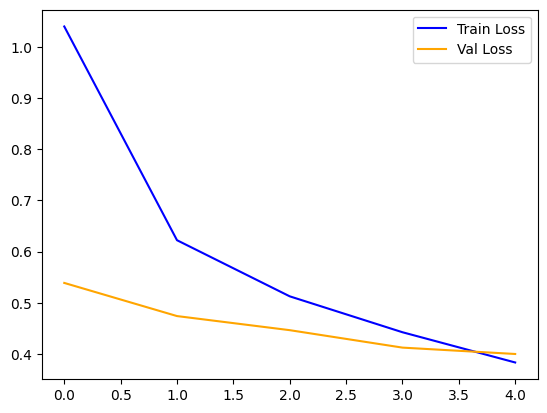

In [ ]:
logs_array = np.array(logs)

plt.plot(logs_array[:, 0], logs_array[:, 1], label="Train Loss", c="b")
plt.plot(logs_array[:, 0], logs_array[:, 2], label="Val Loss", c="orange")

plt.legend()
plt.show()

### 7.6. Evaluate the Model

In [ ]:
probs, preds, targets = eval_model(model=resnet50_model, dataloader=val_dataloader, device=DEVICE)

In [ ]:
# print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy()))
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy(), target_names=class_names))

                    precision    recall  f1-score   support

    baby_back_ribs       0.89      0.86      0.87       100
           baklava       0.90      0.87      0.88       100
          bibimbap       0.97      0.93      0.95       100
        bruschetta       0.73      0.88      0.80       100
      caesar_salad       0.86      0.94      0.90       100
        cheesecake       0.88      0.83      0.86       100
     chicken_curry       0.90      0.85      0.88       100
chicken_quesadilla       0.97      0.86      0.91       100
        crab_cakes       0.86      0.79      0.82       100
         cup_cakes       0.95      0.86      0.90       100
      filet_mignon       0.64      0.80      0.71       100
    fried_calamari       0.96      0.89      0.92       100
          pancakes       0.82      0.90      0.86       100
               pho       0.98      0.94      0.96       100
   red_velvet_cake       0.88      0.94      0.91       100
            samosa       0.82      0.93

## **8. Save and Load**

### 8.0. Save CNN Model

In [ ]:
cnn_model_dict = {
    "model_state_dict": resnet50_model.to("cpu").state_dict(), # Can't deserialize cuda with cpu on loading
    "num_classes": num_classes,
    "batch_size": train_dataloader.batch_size,
    "img_shape": next(iter(train_dataloader))[0][0].shape,
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
    "architecture": str(resnet50_model),
    "train_transfrom":  str(train_transform.transforms),
    "test_transfrom":  str(test_transform.transforms),
    "require_grad_layers": trainable_params,
}

resnet50_model = resnet50_model.to(DEVICE) # Put back model to current device

In [ ]:
torch.save(cnn_model_dict, "pytorch_0006_resnet50_model_2_20p.pth")

Save on Google Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# torch.save(cnn_model_dict, "/content/drive/MyDrive/pytorch_0006_resnet50_model_2_20p.pth")

### 8.1. Load CNN Model

In [ ]:
# Download the pretrained model
import gdown

link = "https://drive.google.com/file/d/10w5QlxOfobDNpEi8P97t7EeLCAhfIb_P/view?usp=sharing" # 20%
out_path = "pytorch_0006_resnet50_model_2_20p.pth"

file_id = link.split("/")[-2]

gdown.download(f'https://drive.google.com/uc?id={file_id}', out_path, quiet=True)

'pytorch_0006_resnet50_model_2_20p.pth'

In [ ]:
cnn_model_dict_l = torch.load("pytorch_0006_resnet50_model_2_20p.pth", weights_only=False)
cnn_model_dict_l.keys()

dict_keys(['model_state_dict', 'num_classes', 'batch_size', 'img_shape', 'optimizer', 'scheduler', 'architecture', 'train_transfrom', 'test_transfrom', 'require_grad_layers'])

In [ ]:
# Load pretrained ResNet50
resnet50_temp = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze the early layers (optional for transfer learning)
for param in resnet50_temp.parameters():
    param.requires_grad = False

In [ ]:
in_features = resnet50_temp.fc.in_features
resnet50_temp.fc = nn.Linear(in_features, cnn_model_dict_l["num_classes"])

In [ ]:
resnet50_temp.load_state_dict(cnn_model_dict_l["model_state_dict"])

<All keys matched successfully>

In [ ]:
resnet50_temp = resnet50_temp.to(DEVICE)

In [ ]:
next(resnet50_temp.parameters()).device

device(type='cuda', index=0)

### 8.2. Eval Loaded Model

In [ ]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)
probs, preds, targets = eval_model(model=resnet50_temp, dataloader=val_dataloader, device=DEVICE)

In [ ]:
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy(), target_names=class_names))

                    precision    recall  f1-score   support

    baby_back_ribs       0.89      0.86      0.87       100
           baklava       0.90      0.87      0.88       100
          bibimbap       0.97      0.93      0.95       100
        bruschetta       0.73      0.88      0.80       100
      caesar_salad       0.86      0.94      0.90       100
        cheesecake       0.88      0.83      0.86       100
     chicken_curry       0.90      0.85      0.88       100
chicken_quesadilla       0.97      0.86      0.91       100
        crab_cakes       0.86      0.79      0.82       100
         cup_cakes       0.95      0.86      0.90       100
      filet_mignon       0.64      0.80      0.71       100
    fried_calamari       0.96      0.89      0.92       100
          pancakes       0.82      0.90      0.86       100
               pho       0.98      0.94      0.96       100
   red_velvet_cake       0.88      0.94      0.91       100
            samosa       0.82      0.93